# Breast Cancer Diagnostic Classification Pipeline
# **Predicting tumor malignancy (Benign vs. Malignant) using the Wisconsin Diagnostic dataset via Logistic Regression and Random Forest classifiers.**

In [3]:
# Importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

In [4]:
# Dataset Loading & Structure Check

cancer = load_breast_cancer()
df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target  # 0: Malignant, 1: Benign

print(f"Dataset Shape: {df.shape}")
print("Class Distribution:")
print(df['target'].value_counts())

Dataset Shape: (569, 31)
Class Distribution:
target
1    357
0    212
Name: count, dtype: int64


/tmp/ipykernel_445/600431108.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


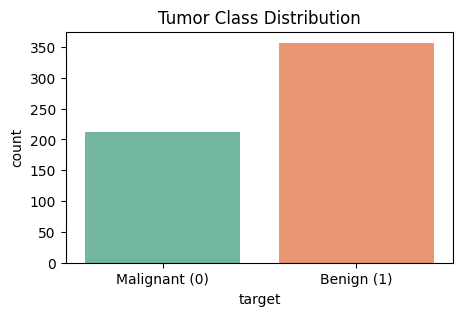

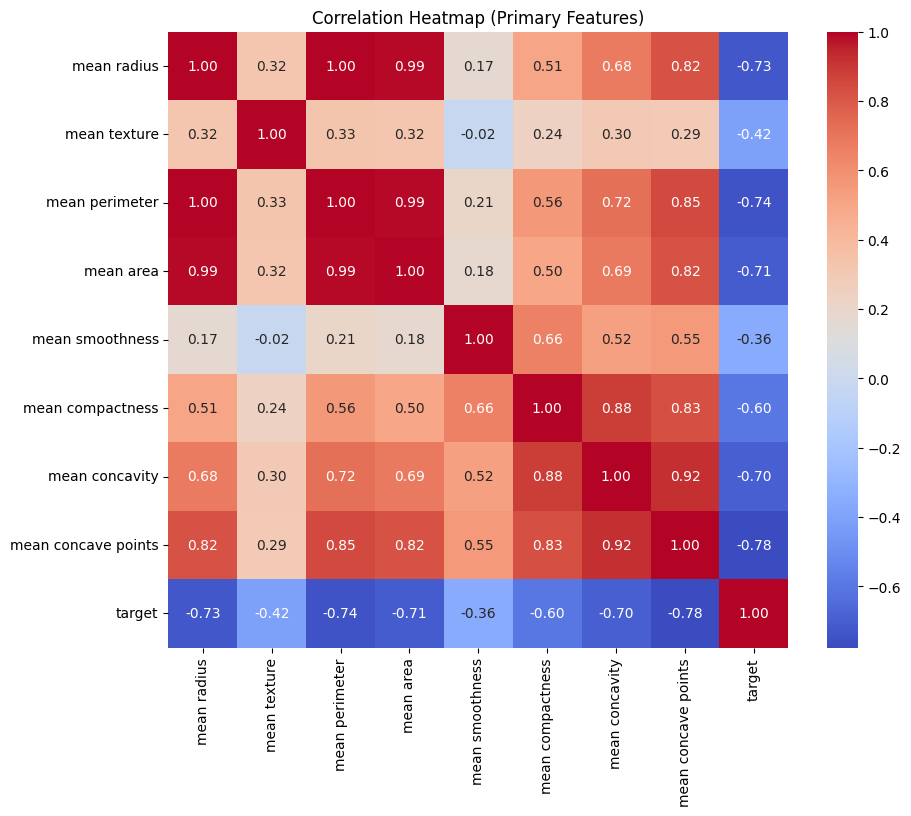

In [5]:
# Exploratory Data Analysis (EDA Plots)

# 1. Target Distribution Plot
plt.figure(figsize=(5, 3))
sns.countplot(x='target', data=df, palette='Set2')
plt.xticks([0, 1], ['Malignant (0)', 'Benign (1)'])
plt.title('Tumor Class Distribution')
plt.show()

# 2. Correlation Heatmap (Selected Features)
plt.figure(figsize=(10, 8))
sample_features = list(cancer.feature_names[:8]) + ['target']
sns.heatmap(df[sample_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Primary Features)')
plt.show()

In [7]:
# Train-Test Split & Feature Standardization

X = df.drop(columns=['target'])
y = df['target']

# Stratified split to preserve class ratios
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# Model Training (Logistic Regression & Random froest)
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [9]:
# Model Evaluation & Classification report

lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression Performance ===")
print(classification_report(y_test, lr_preds, target_names=['Malignant', 'Benign']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_probs):.4f}")

=== Logistic Regression Performance ===
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

ROC-AUC Score: 0.9954


In [ ]:
# Visualizing Confuaion Matric & ROC Curve

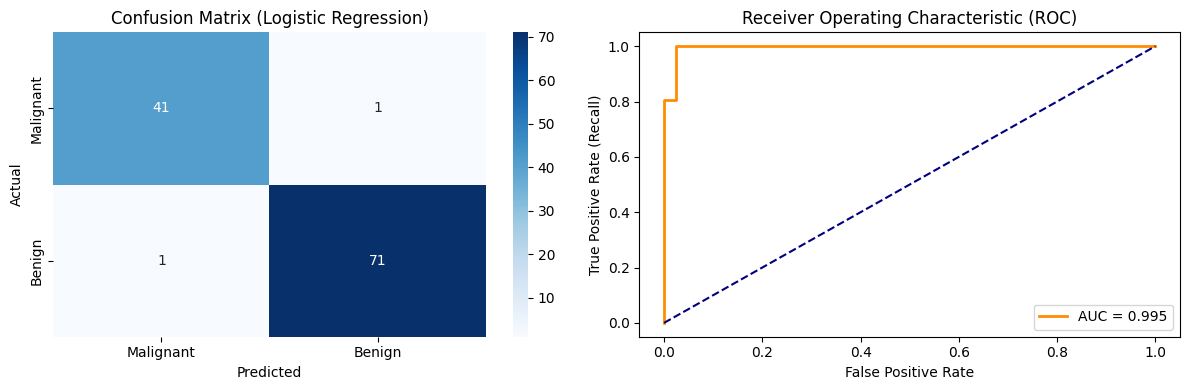

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
ax[0].set_title('Confusion Matrix (Logistic Regression)')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, lr_probs)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_score(y_test, lr_probs):.3f}')
ax[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate (Recall)')
ax[1].set_title('Receiver Operating Characteristic (ROC)')
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

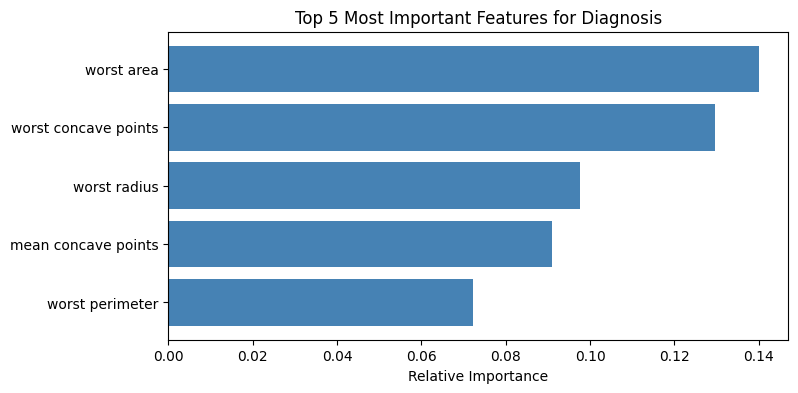

In [11]:
# Random Forest Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-5:]  # Top 5 features

plt.figure(figsize=(8, 4))
plt.title("Top 5 Most Important Features for Diagnosis")
plt.barh(range(len(indices)), importances[indices], color='steelblue', align='center')
plt.yticks(range(len(indices)), [cancer.feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

/tmp/ipykernel_445/3193969820.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2', ax=ax[0])
/tmp/ipykernel_445/3193969820.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Malignant (0)', 'Benign (1)'])


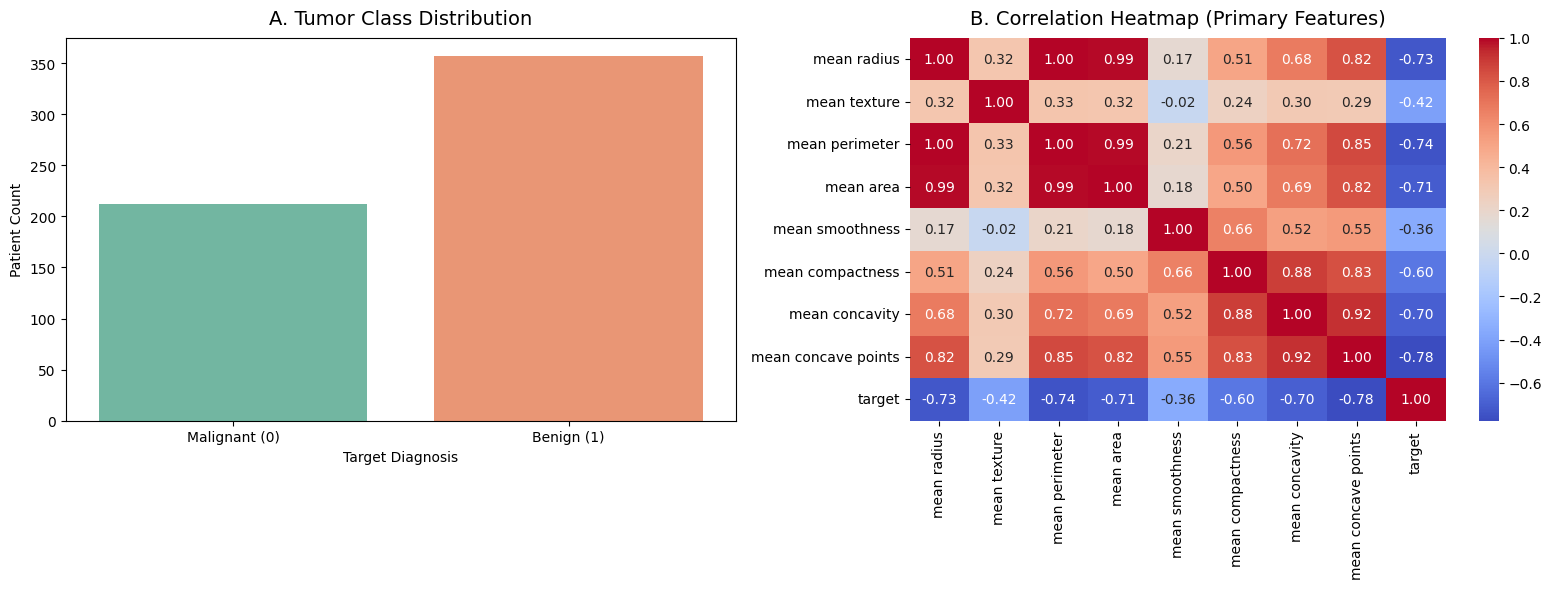

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# 1. Clear previous figures & setup subplots
plt.close('all')
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: Target Distribution
sns.countplot(x='target', data=df, palette='Set2', ax=ax[0])
ax[0].set_xticklabels(['Malignant (0)', 'Benign (1)'])
ax[0].set_title('A. Tumor Class Distribution', fontsize=14, pad=10)
ax[0].set_xlabel('Target Diagnosis')
ax[0].set_ylabel('Patient Count')

# Right Plot: Clean Correlation Heatmap
sample_features = list(cancer.feature_names[:8]) + ['target']
sns.heatmap(df[sample_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax[1], cbar=True)
ax[1].set_title('B. Correlation Heatmap (Primary Features)', fontsize=14, pad=10)

# 2. Perfect spacing & auto download
plt.tight_layout()
plt.savefig('eda_correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Direct computer download
files.download('eda_correlation_analysis.png')